# 03 · Baseline

A model is only useful relative to something trivial. Before the feature-stage experiments we establish:

1. **Naive baseline** — predict every film's revenue as the median historical log-revenue.
2. **Simple numeric ML baseline** — linear regression on budget/runtime/release-date numbers only.
3. **Initial XGBoost** on the *basic* feature set.

**Target**: `log1p(revenue)`. Metrics reported on that log scale (MAE/RMSE/R²) plus a raw-dollar RMSE after back-transformation.

**Split** (out-of-time, so the test set represents future films):

| split | years | size |
|---|---|---|
| train | ≤ 2016 | 6,262 |
| validation | 2017–2021 | 916 |
| test | ≥ 2022 | 862 |


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


In [3]:
from scripts.prepare_dataset import prepare_ml_dataset
from scripts.evaluation import (
    time_split, build_matrix, evaluate_predictions, log_experiment,
    run_experiment, read_experiment_log, FEATURE_SETS, XGB_PARAMS,
    TRAIN_END_YEAR, VAL_END_YEAR,
)
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

## 1. Data and split

train/val/test: 6262 916 862


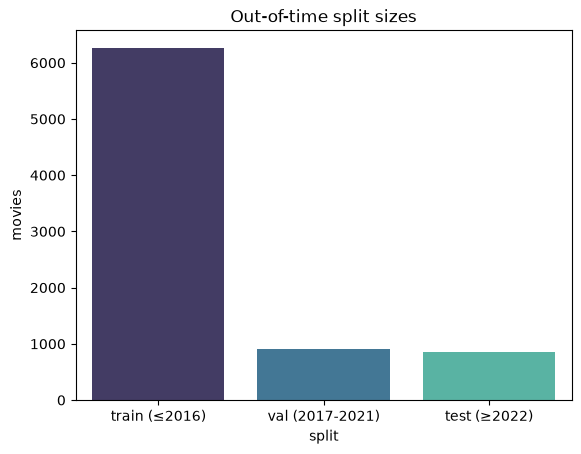

In [4]:
ds = prepare_ml_dataset()
train, val, test = time_split(ds)
print("train/val/test:", len(train), len(val), len(test))

sizes = pd.DataFrame({
    'split': ['train (≤2016)', f'val ({TRAIN_END_YEAR+1}-{VAL_END_YEAR})', f'test (≥{VAL_END_YEAR+1})'],
    'movies': [len(train), len(val), len(test)],
})
sns.barplot(data=sizes, x='split', y='movies', hue='split', legend=False, palette='mako')
plt.ylabel('movies')
plt.title('Out-of-time split sizes')
plt.show()

## 2. Naive baseline (median log-revenue)

In [5]:
import numpy as np

naive_log = np.log1p(train['revenue']).median()
pred = np.full(len(test), naive_log)
m = evaluate_predictions(np.log1p(test['revenue']), pred)
print(f"naive median log1p(revenue) = {naive_log:.2f}  (~${np.expm1(naive_log)/1e6:.0f}M)")
m

naive median log1p(revenue) = 17.25  (~$31M)


{'mae': 1.3369179075254527,
 'rmse': np.float64(1.6381378232894168),
 'r2': -0.0008633908931081624,
 'raw_rmse': np.float64(273192863.57974553),
 'raw_mae': 109816387.2756865}

In [6]:
log_experiment({
    'experiment_id': 'naive',
    'feature_set': 'naive',
    'model': 'median',
    'hyperparameters': 'median log1p revenue',
    'train_period': f'<={TRAIN_END_YEAR}', 'validation_period': f'{TRAIN_END_YEAR+1}-{VAL_END_YEAR}', 'test_period': f'>={VAL_END_YEAR+1}',
    'mae': round(m['mae'], 4), 'rmse': round(m['rmse'], 4), 'r2': round(m['r2'], 4),
    'raw_rmse': round(m['raw_rmse'], 0), 'raw_mae': round(m['raw_mae'], 0),
    'notes': 'baseline: median train log revenue',
})

,experiment_id,feature_set,model,hyperparameters,train_period,validation_period,test_period,mae,rmse,r2,raw_rmse,raw_mae,notes
0,naive,naive,median,median log1p revenue,<=2016,2017-2021,>=2022,1.3369,1.6381,-0.0009,273192864.0,109816387.0,baseline: median train log revenue


## 3. Simple numeric linear baseline

In [7]:
num_conf = {
    'numeric': ['log_budget', 'log_runtime', 'release_year', 'release_month', 'release_quarter', 'release_day_of_week'],
    'freq': [],
    'ohe': [],
}
X_train, encoders = build_matrix(train, num_conf, fit_encoders=True)
X_val, _ = build_matrix(val, num_conf, encoders=encoders)
X_test, _ = build_matrix(test, num_conf, encoders=encoders)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression()),
])
pipe.fit(X_train, np.log1p(train['revenue']))
pred_lin = pipe.predict(X_test)
m_lin = evaluate_predictions(np.log1p(test['revenue']), pred_lin)
m_lin

{'mae': 0.9524276659908579,
 'rmse': np.float64(1.1867412378514597),
 'r2': 0.47472588959421214,
 'raw_rmse': np.float64(226293574.62371302),
 'raw_mae': 86535524.32634829}

In [8]:
log_experiment({
    'experiment_id': 'linear_bare',
    'feature_set': 'basic_numeric',
    'model': 'LinearRegression',
    'hyperparameters': 'median-impute+standardise',
    'train_period': f'<={TRAIN_END_YEAR}', 'validation_period': f'{TRAIN_END_YEAR+1}-{VAL_END_YEAR}', 'test_period': f'>={VAL_END_YEAR+1}',
    'mae': round(m_lin['mae'], 4), 'rmse': round(m_lin['rmse'], 4), 'r2': round(m_lin['r2'], 4),
    'raw_rmse': round(m_lin['raw_rmse'], 0), 'raw_mae': round(m_lin['raw_mae'], 0),
    'notes': 'numbers only, no categoricals',
})

,experiment_id,feature_set,model,hyperparameters,train_period,validation_period,test_period,mae,rmse,r2,raw_rmse,raw_mae,notes
0,naive,naive,median,median log1p revenue,<=2016,2017-2021,>=2022,1.3369,1.6381,-0.0009,273192864.0,109816387.0,baseline: median train log revenue
1,linear_bare,basic_numeric,LinearRegression,median-impute+standardise,<=2016,2017-2021,>=2022,0.9524,1.1867,0.4747,226293575.0,86535524.0,"numbers only, no categoricals"


## 4. Initial XGBoost on the *basic* feature set

In [9]:
res_xgb = run_experiment('xgb_basic', 'basic', ds, XGBRegressor(**XGB_PARAMS), XGB_PARAMS, notes='initial XGBoost on basic set')
res_xgb['test_metrics']

{'mae': 0.9020369076534864,
 'rmse': np.float64(1.1518423069963506),
 'r2': 0.5051654895176296,
 'raw_rmse': np.float64(188219797.48568505),
 'raw_mae': 80820416.07366589}

## 5. Baseline summary

In [10]:
log = read_experiment_log()
log[log['experiment_id'].isin(['naive', 'linear_bare', 'xgb_basic'])][
    ['experiment_id', 'model', 'mae', 'rmse', 'r2', 'raw_rmse', 'raw_mae']
]

,experiment_id,model,mae,rmse,r2,raw_rmse,raw_mae
0,naive,median,1.3369,1.6381,-0.0009,273192864.0,109816387.0
1,linear_bare,LinearRegression,0.9524,1.1867,0.4747,226293575.0,86535524.0
2,xgb_basic,XGBRegressor,0.9020,1.1518,0.5052,188219797.0,80820416.0


**Takeaways**

- The naive median gets an R² of ~0 - the trivial guess is not good, so there is real signal to capture.
- A plain linear model on numbers beats the median but sits far below the tree model.
- XGBoost with the *basic* set is the reference point; every later feature group is measured against it in `04.model_comparison.ipynb`.